In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# File paths
GAS_FILE = 'US_state.csv'
POLICY_FILE = 'Europe.xlsx'
SHIPPING_FILE = 'Strait of Hormuz Disruption.csv'
ASIA_FILE = 'Asia.csv'

gas_df = pd.read_csv(GAS_FILE)
policy_df = pd.read_excel(POLICY_FILE)
shipping_df = pd.read_csv(SHIPPING_FILE)
asia_df = pd.read_csv(ASIA_FILE)

# Load datasets
print(gas_df.head())
print(policy_df.head())
print(asia_df.head())
print(shipping_df.head())

print(gas_df.head())
print(gas_df.info())
print(gas_df.describe())
print(policy_df.head())
print(policy_df.info())
print(policy_df.describe(include='all'))
print(shipping_df.head())
print(shipping_df.info())
print(shipping_df.describe())
print(asia_df.head())
print(asia_df.info())
print(asia_df.describe())

print('\nGas Data')
print(gas_df.isnull().sum())

print('\nPolicy Data')
print(policy_df.isnull().sum())

print('\nShipping Data')
print(shipping_df.isnull().sum())

print('\nAsia Data')
print(asia_df.isnull().sum())

        state region  gas_price_mar19_2026  gas_price_prewar_feb27  \
0  California   West                  5.53                    4.52   
1  Washington   West                  5.15                    4.18   
2      Hawaii   West                  5.07                    4.02   
3      Oregon   West                  4.70                    3.82   
4      Nevada   West                  4.66                    3.72   

   gas_price_jan08_2026  price_increase_since_war  pct_increase_since_war  \
0                  3.88                      1.01                    22.3   
1                  3.42                      0.97                    23.2   
2                  3.78                      1.05                    26.1   
3                  3.22                      0.88                    23.0   
4                  3.18                      0.94                    25.3   

   price_vs_national_avg                                         source  
0                   1.65  AAA State Gas Pr

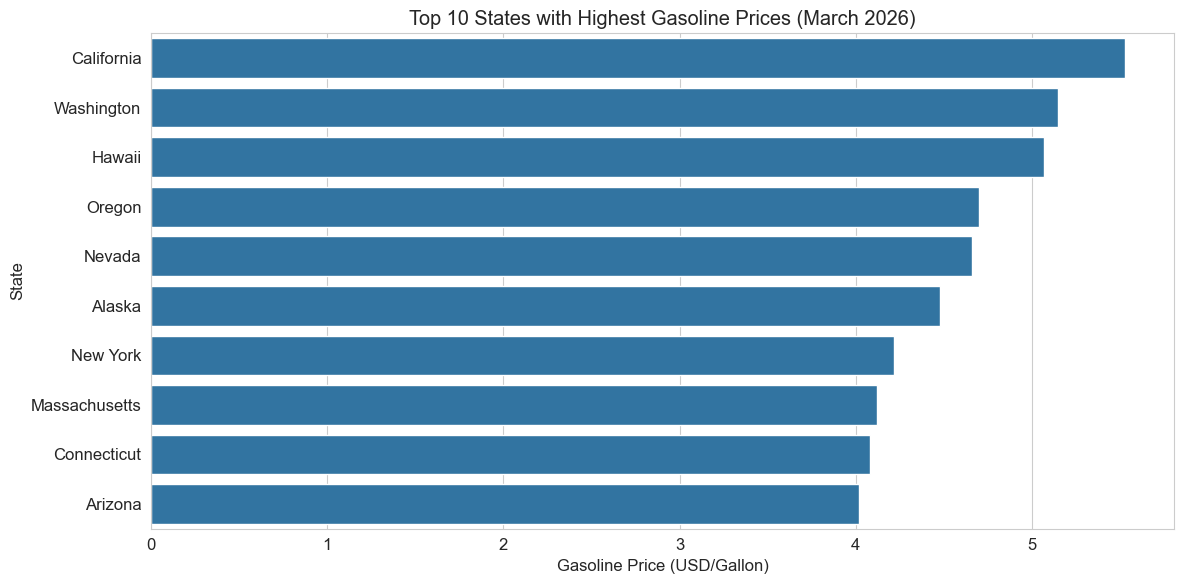

In [2]:
highest_prices = gas_df.sort_values(
    'gas_price_mar19_2026',
    ascending=False
)

sns.barplot(
    data=highest_prices.head(10),
    x='gas_price_mar19_2026',
    y='state'
)

plt.title('Top 10 States with Highest Gasoline Prices (March 2026)')
plt.xlabel('Gasoline Price (USD/Gallon)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

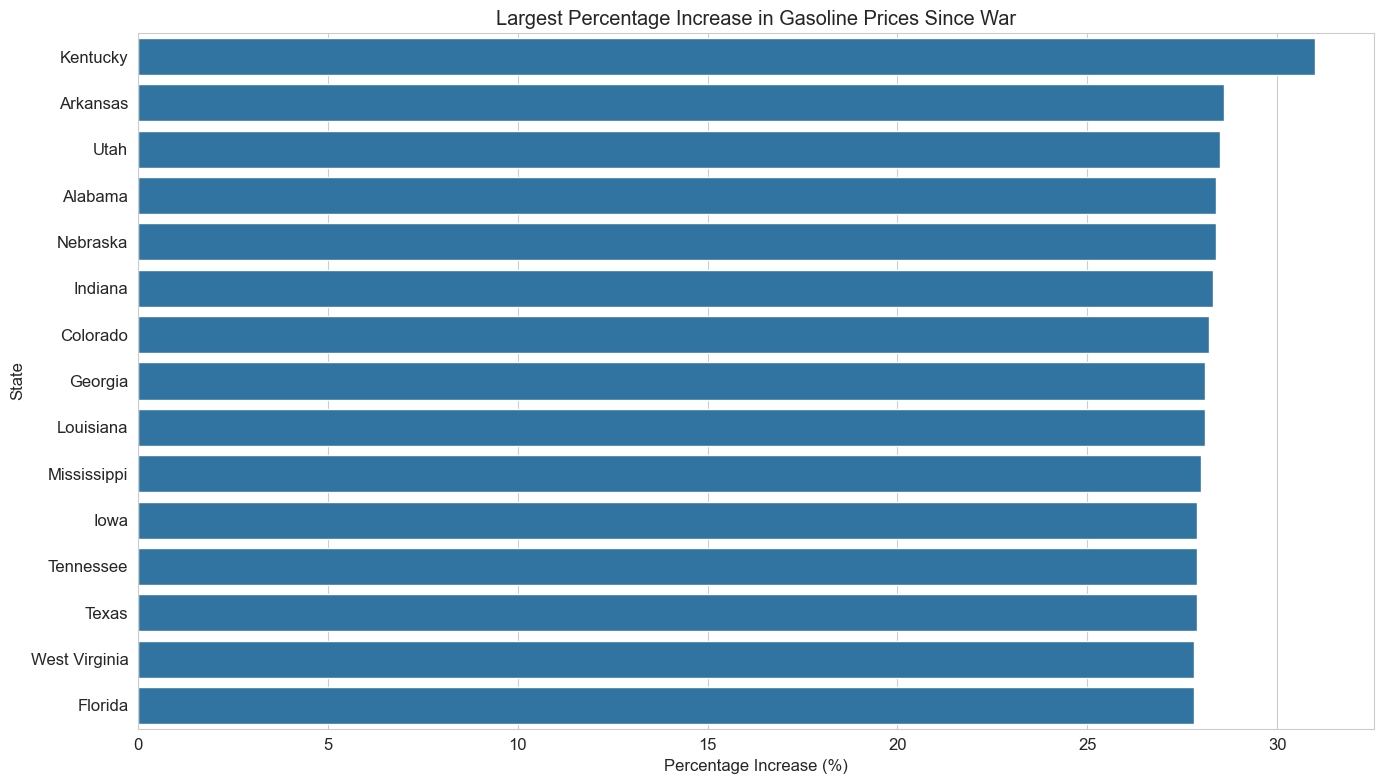

In [3]:
largest_increase = gas_df.sort_values(
    'pct_increase_since_war',
    ascending=False
)

plt.figure(figsize=(14,8))

sns.barplot(
    data=largest_increase.head(15),
    x='pct_increase_since_war',
    y='state'
)

plt.title('Largest Percentage Increase in Gasoline Prices Since War')
plt.xlabel('Percentage Increase (%)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

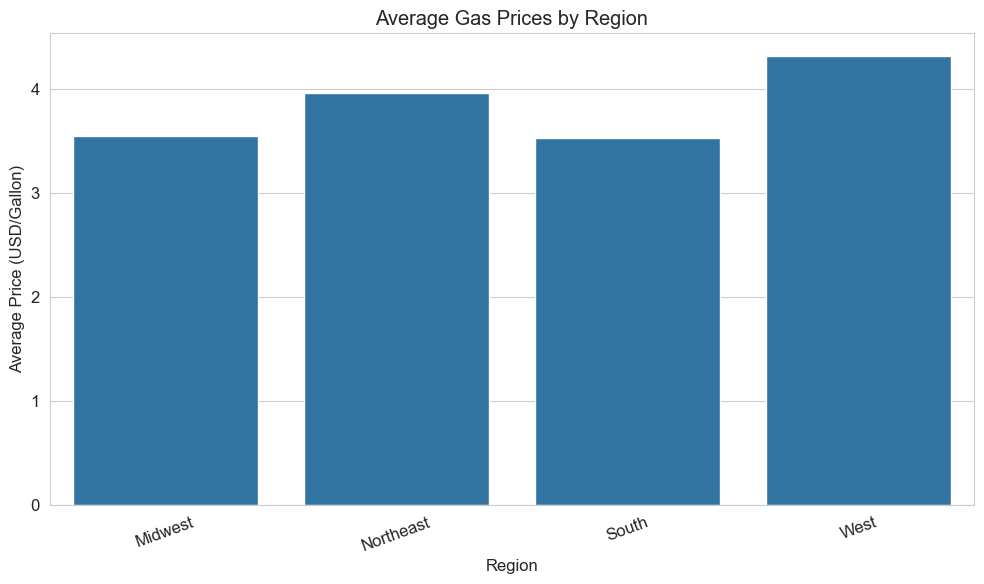

In [4]:
regional_avg = gas_df.groupby('region')['gas_price_mar19_2026'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=regional_avg,
    x='region',
    y='gas_price_mar19_2026'
)

plt.title('Average Gas Prices by Region')
plt.xlabel('Region')
plt.ylabel('Average Price (USD/Gallon)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

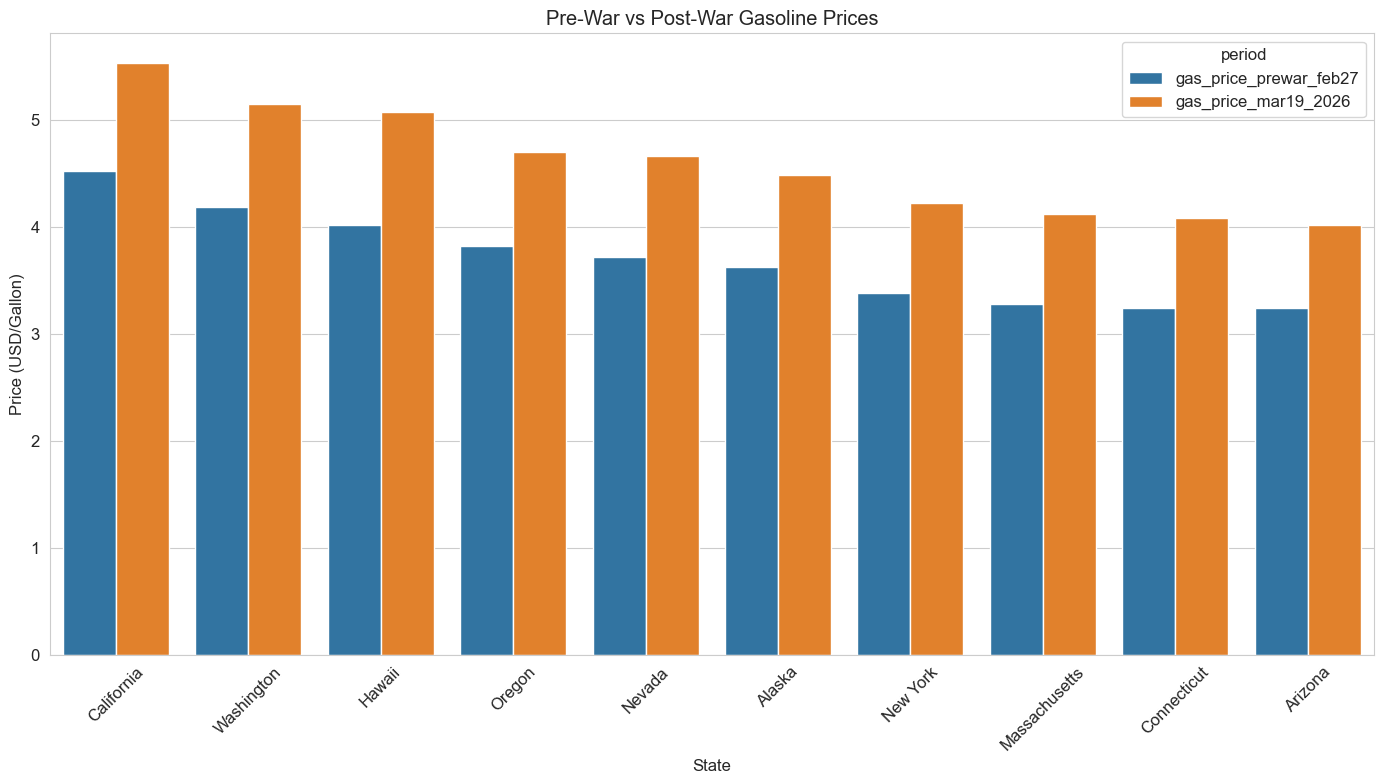

In [5]:
comparison_df = gas_df[[
    'state',
    'gas_price_prewar_feb27',
    'gas_price_mar19_2026'
]].copy()

comparison_df = comparison_df.sort_values(
    'gas_price_mar19_2026',
    ascending=False
).head(10)

comparison_melt = comparison_df.melt(
    id_vars='state',
    var_name='period',
    value_name='price'
)

plt.figure(figsize=(14,8))

sns.barplot(
    data=comparison_melt,
    x='state',
    y='price',
    hue='period'
)

plt.title('Pre-War vs Post-War Gasoline Prices')
plt.xlabel('State')
plt.ylabel('Price (USD/Gallon)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

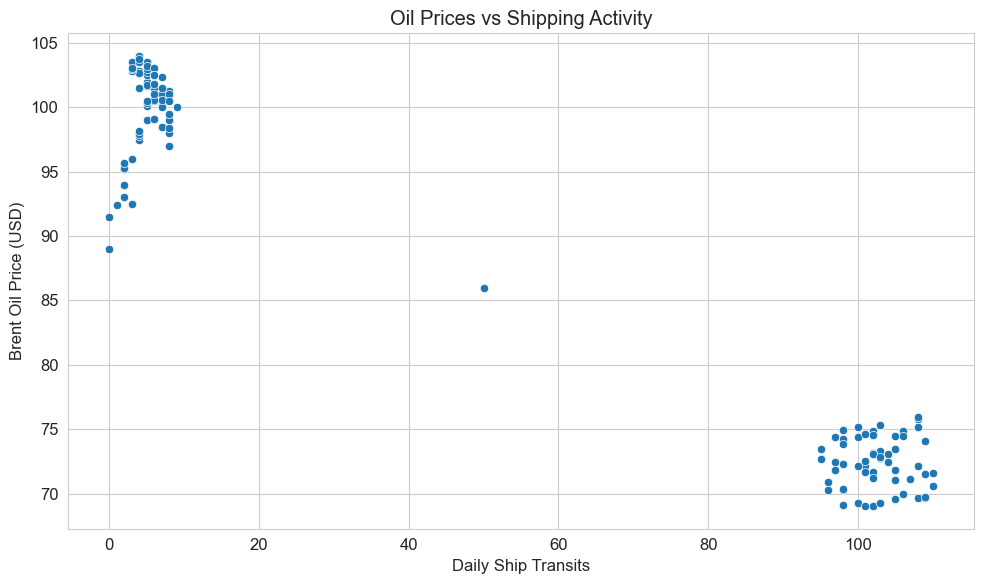

In [6]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=shipping_df,
    x='daily_ship_transits',
    y='brent_crude_usd_bbl'
)

plt.title('Oil Prices vs Shipping Activity')
plt.xlabel('Daily Ship Transits')
plt.ylabel('Brent Oil Price (USD)')
plt.tight_layout()
plt.show()

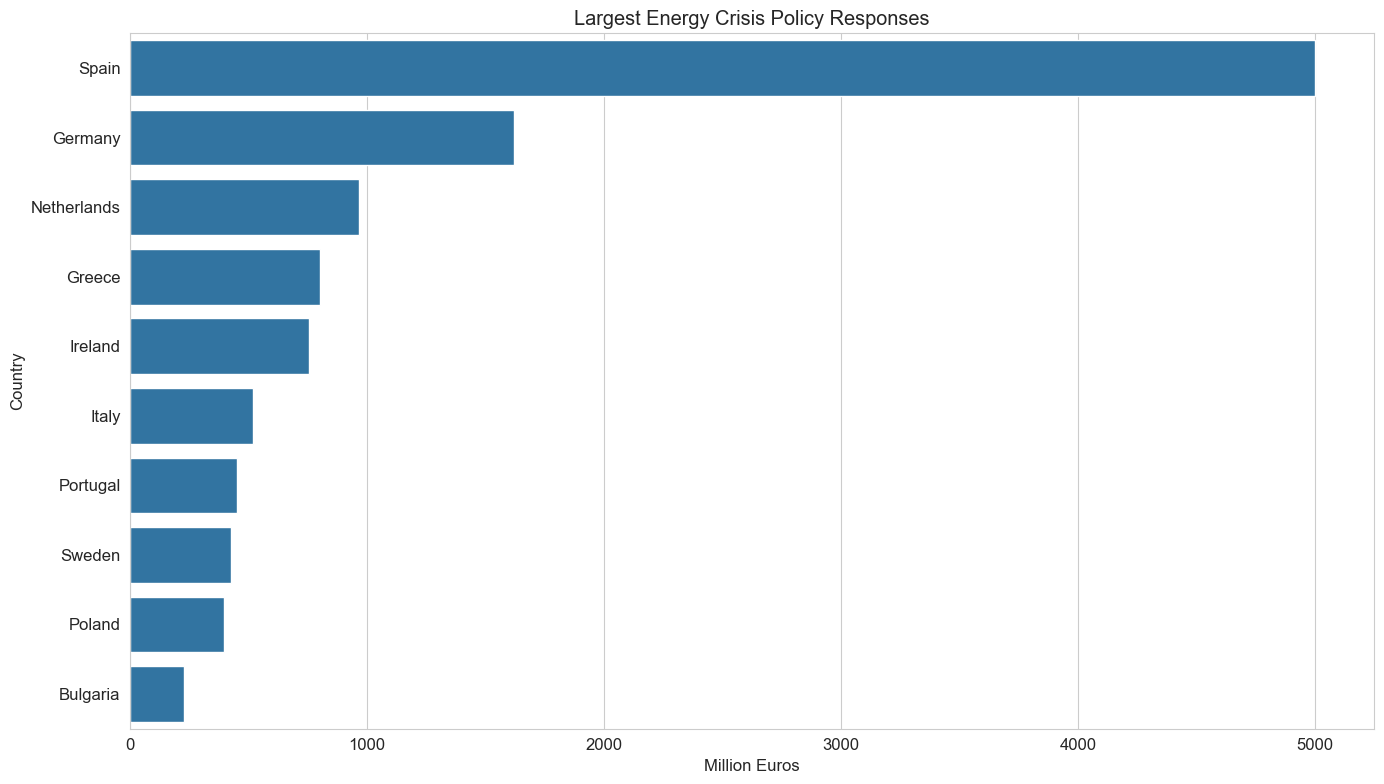

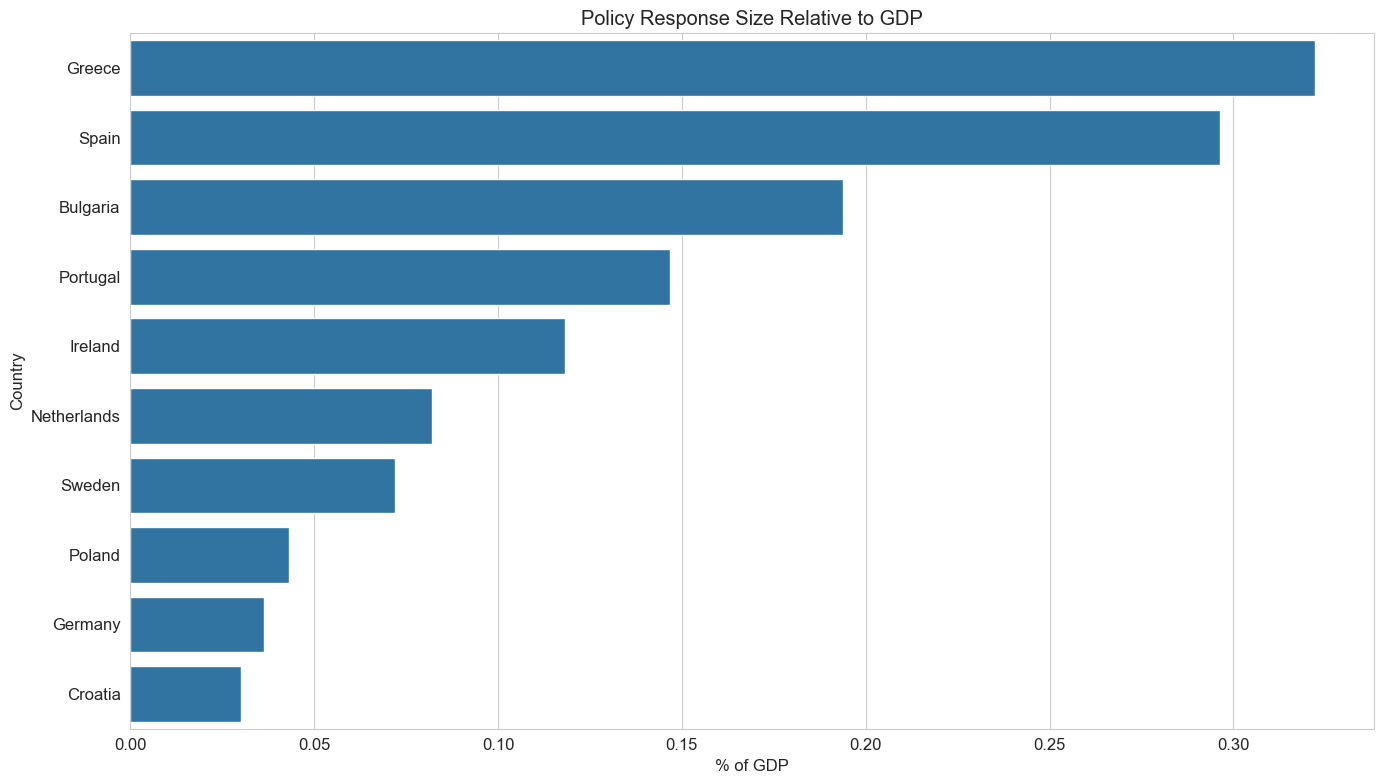

In [7]:
policy_totals = (
    policy_df.groupby('Country')
    ['Total Amount (in million euros)']
    .sum()
    .reset_index()
    .sort_values(
        'Total Amount (in million euros)',
        ascending=False
    )
)

plt.figure(figsize=(14,8))

sns.barplot(
    data=policy_totals.head(10),
    x='Total Amount (in million euros)',
    y='Country'
)

plt.title('Largest Energy Crisis Policy Responses')
plt.xlabel('Million Euros')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Visualization 12: Policy Measures as % of GDP
# ------------------------------------------------------------

policy_gdp = (
    policy_df.groupby('Country')['Measure in % of GDP']
    .sum()
    .reset_index()
    .sort_values('Measure in % of GDP', ascending=False)
)

plt.figure(figsize=(14,8))

sns.barplot(
    data=policy_gdp.head(10),
    x='Measure in % of GDP',
    y='Country'
)

plt.title('Policy Response Size Relative to GDP')
plt.xlabel('% of GDP')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

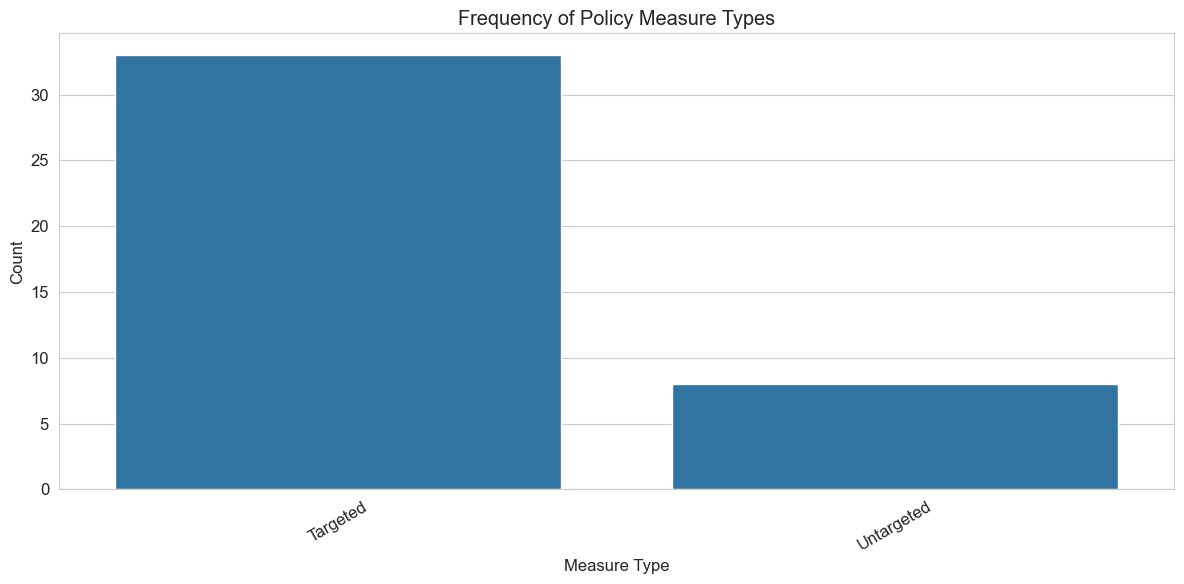

In [8]:
measure_counts = (
    policy_df['Broad Measure Type']
    .value_counts()
    .reset_index()
)

measure_counts.columns = ['measure_type', 'count']

plt.figure(figsize=(12,6))

sns.barplot(
    data=measure_counts,
    x='measure_type',
    y='count'
)

plt.title('Frequency of Policy Measure Types')
plt.xlabel('Measure Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

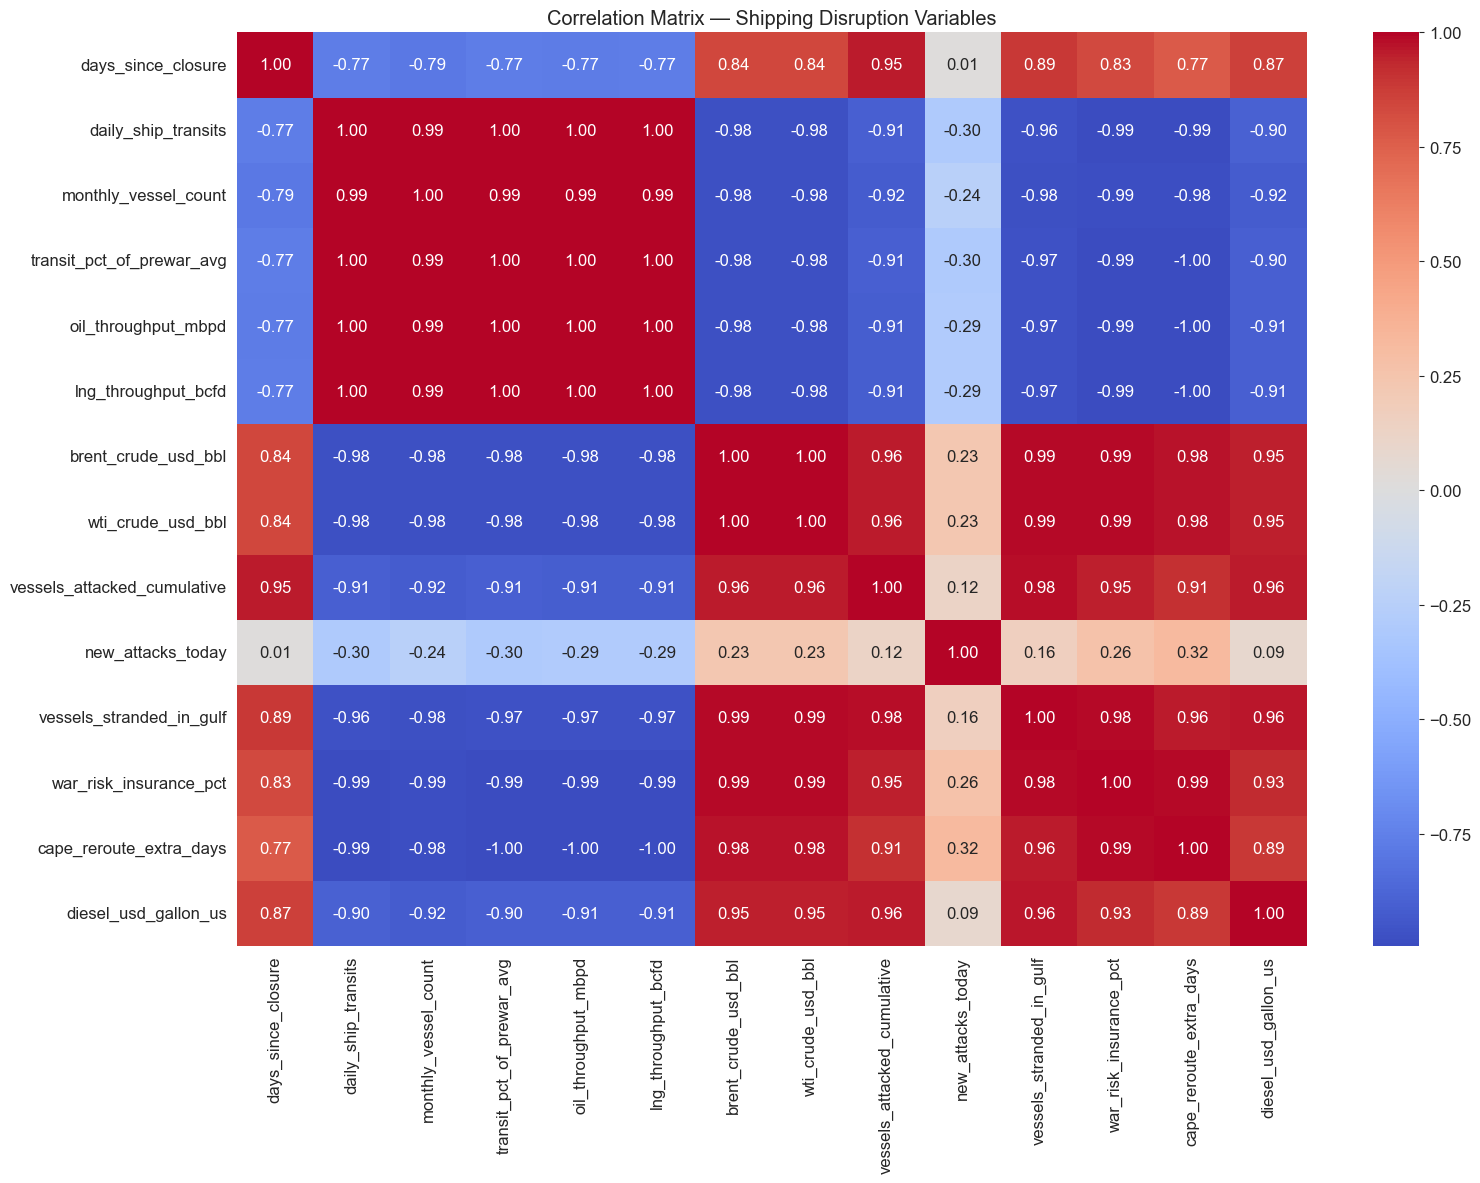

In [9]:
shipping_numeric = shipping_df.select_dtypes(include=np.number)

corr_matrix = shipping_numeric.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix — Shipping Disruption Variables')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Country')

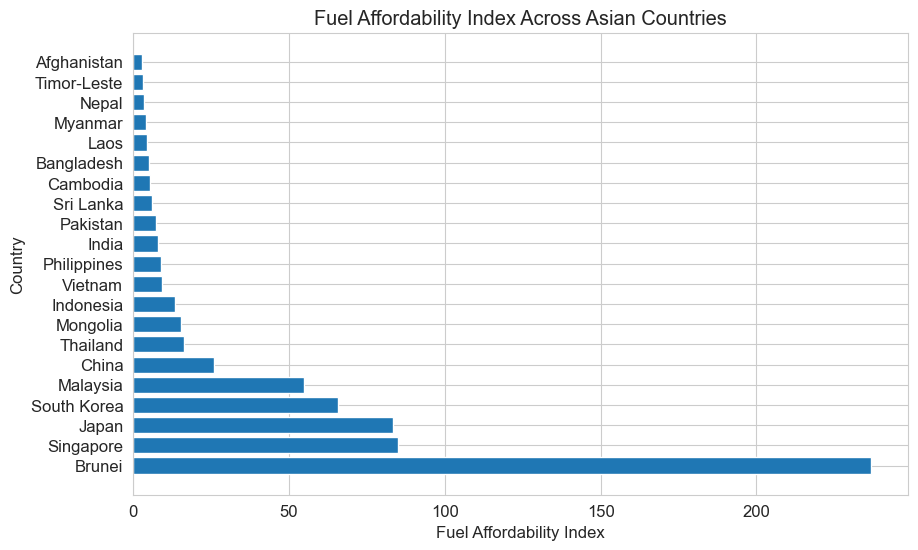

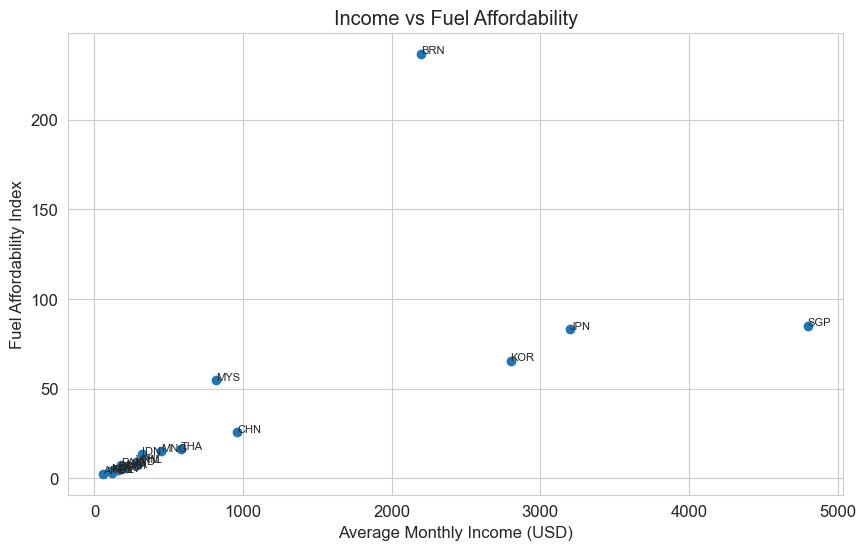

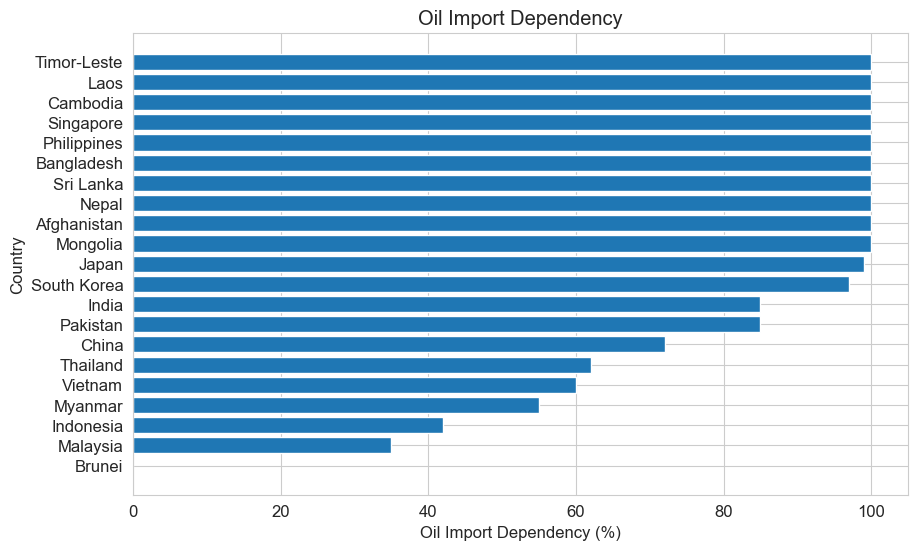

In [10]:
asia_df = asia_df[asia_df["country"] != "Taiwan"]
top = asia_df.sort_values(
    "fuel_affordability_index",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.barh(
    top["country"],
    top["fuel_affordability_index"]
)

plt.title("Fuel Affordability Index Across Asian Countries")
plt.xlabel("Fuel Affordability Index")
plt.ylabel("Country")

plt.figure(figsize=(10, 6))

plt.scatter(
    asia_df["avg_monthly_income_usd"],
    asia_df["fuel_affordability_index"]
)

for _, row in asia_df.iterrows():
    plt.annotate(
        row["iso3"],
        (
            row["avg_monthly_income_usd"],
            row["fuel_affordability_index"]
        ),
        fontsize=8
    )

plt.title("Income vs Fuel Affordability")
plt.xlabel("Average Monthly Income (USD)")
plt.ylabel("Fuel Affordability Index")

oil = asia_df.sort_values(
    "oil_import_dependency_pct",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    oil["country"],
    oil["oil_import_dependency_pct"]
)

plt.title("Oil Import Dependency")
plt.xlabel("Oil Import Dependency (%)")
plt.ylabel("Country")

Features Used:
['days_since_closure', 'daily_ship_transits', 'monthly_vessel_count', 'transit_pct_of_prewar_avg', 'oil_throughput_mbpd', 'lng_throughput_bcfd', 'wti_crude_usd_bbl', 'vessels_attacked_cumulative', 'new_attacks_today', 'vessels_stranded_in_gulf', 'war_risk_insurance_pct', 'cape_reroute_extra_days', 'diesel_usd_gallon_us']
MAE  : 0.023
RMSE : 0.032
R²   : 1.000
MAE  : 0.299
RMSE : 0.364
R²   : 0.945
R² Gap: 0.055
No significant overfitting detected


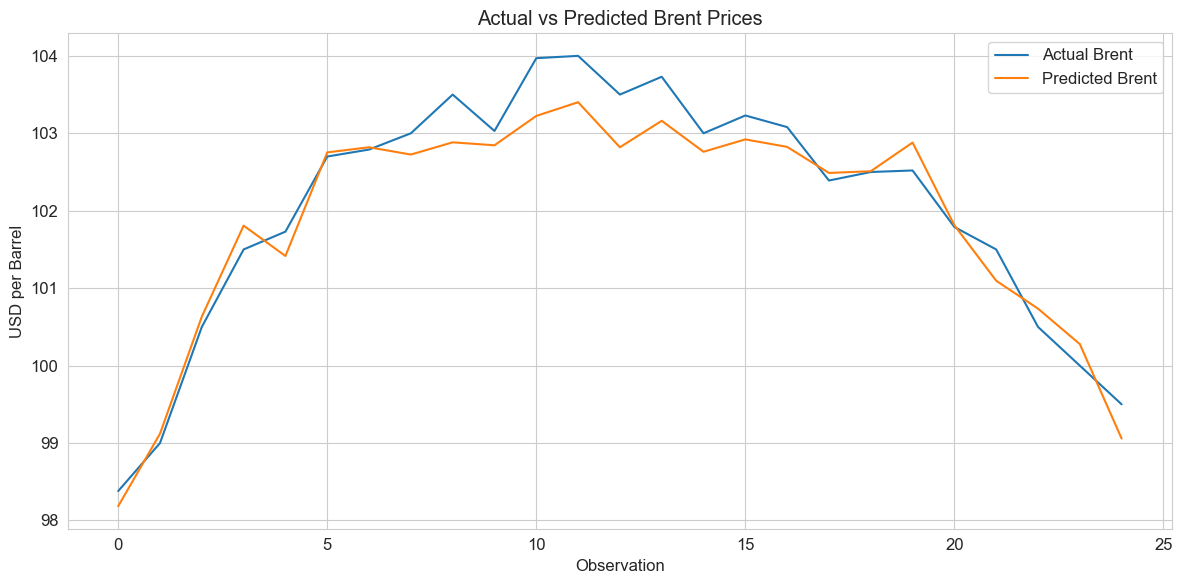

                        Feature  Importance
0            days_since_closure    0.994105
6             wti_crude_usd_bbl    0.005686
10       war_risk_insurance_pct    0.000075
4           oil_throughput_mbpd    0.000043
12         diesel_usd_gallon_us    0.000031
1           daily_ship_transits    0.000022
5           lng_throughput_bcfd    0.000019
8             new_attacks_today    0.000019
2          monthly_vessel_count    0.000000
3     transit_pct_of_prewar_avg    0.000000
7   vessels_attacked_cumulative    0.000000
9      vessels_stranded_in_gulf    0.000000
11      cape_reroute_extra_days    0.000000


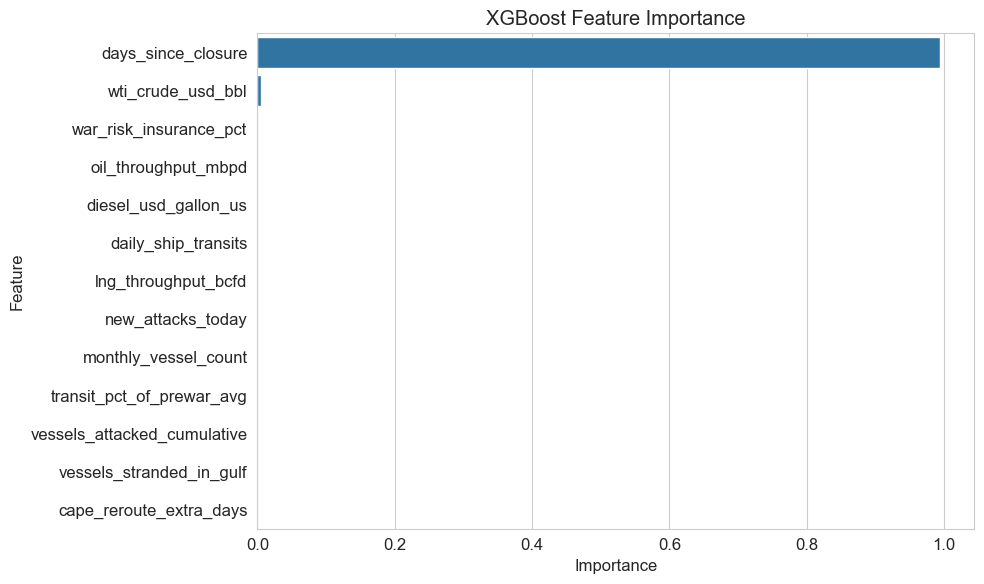

In [11]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

shipping_df['date'] = pd.to_datetime(
    shipping_df['date']
)

shipping_df = shipping_df.sort_values(
    'date'
)

# Target variable

target = 'brent_crude_usd_bbl'

# Use all numeric variables except target

features = [
    col for col in shipping_df.select_dtypes(
        include=np.number
    ).columns
    if col != target
]

print("Features Used:")
print(features)

X = shipping_df[features]
y = shipping_df[target]

split = int(len(shipping_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

train_preds = model.predict(
    X_train
)

test_preds = model.predict(
    X_test
)

train_mae = mean_absolute_error(
    y_train,
    train_preds
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_preds
    )
)

train_r2 = r2_score(
    y_train,
    train_preds
)

test_mae = mean_absolute_error(
    y_test,
    test_preds
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_preds
    )
)

test_r2 = r2_score(
    y_test,
    test_preds
)

print(f"MAE  : {train_mae:.3f}")
print(f"RMSE : {train_rmse:.3f}")
print(f"R²   : {train_r2:.3f}")

print(f"MAE  : {test_mae:.3f}")
print(f"RMSE : {test_rmse:.3f}")
print(f"R²   : {test_r2:.3f}")

r2_gap = train_r2 - test_r2

print(f"R² Gap: {r2_gap:.3f}")

if r2_gap < 0.10:
    print("No significant overfitting detected")

elif r2_gap < 0.20:
    print("Mild overfitting detected")

else:
    print("Possible overfitting detected")

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Brent'
)

plt.plot(
    test_preds,
    label='Predicted Brent'
)

plt.title(
    'Actual vs Predicted Brent Prices'
)

plt.xlabel('Observation')
plt.ylabel('USD per Barrel')

plt.legend()

plt.tight_layout()

plt.show()

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)


plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'XGBoost Feature Importance'
)

plt.tight_layout()

plt.show()

In [12]:
#Linear regression model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train, y_train)
train_preds = lr.predict(X_train)
test_preds = lr.predict(X_test)

train_mae = mean_absolute_error(
    y_train,
    train_preds
)

test_mae = mean_absolute_error(
    y_test,
    test_preds
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_preds
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_preds
    )
)

train_r2 = r2_score(
    y_train,
    train_preds
)

test_r2 = r2_score(
    y_test,
    test_preds
)


print("\nTRAIN")

print(f"MAE  : {train_mae:.3f}")
print(f"RMSE : {train_rmse:.3f}")
print(f"R²   : {train_r2:.3f}")

print("\nTEST")

print(f"MAE  : {test_mae:.3f}")
print(f"RMSE : {test_rmse:.3f}")
print(f"R²   : {test_r2:.3f}")


TRAIN
MAE  : 0.187
RMSE : 0.229
R²   : 1.000

TEST
MAE  : 0.249
RMSE : 0.292
R²   : 0.965


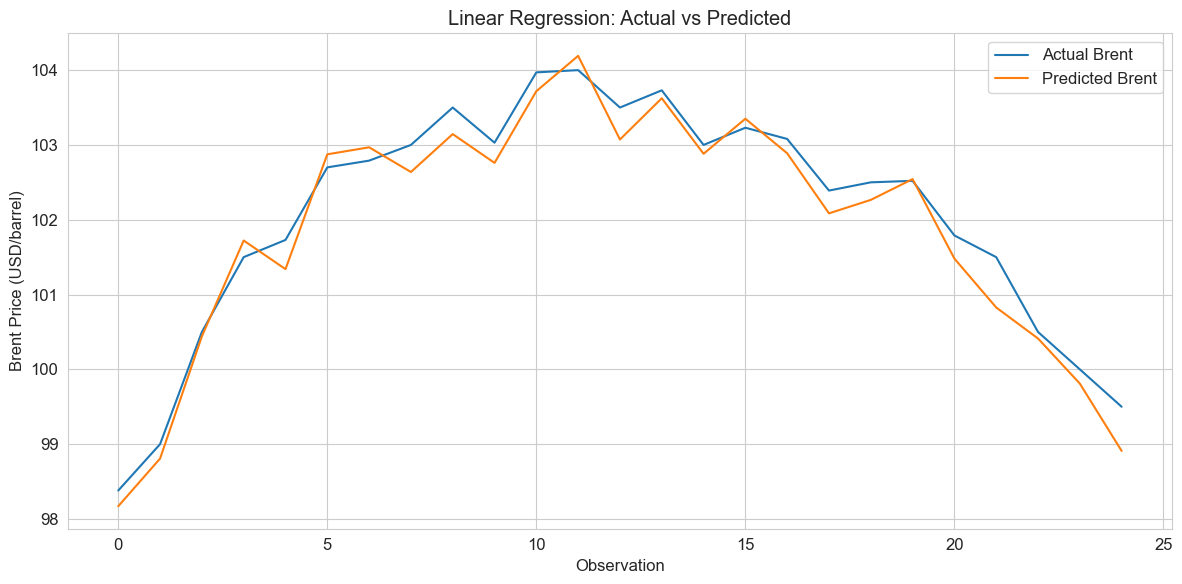

In [13]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Brent'
)

plt.plot(
    test_preds,
    label='Predicted Brent'
)

plt.title(
    'Linear Regression: Actual vs Predicted'
)

plt.xlabel('Observation')
plt.ylabel('Brent Price (USD/barrel)')

plt.legend()

plt.tight_layout()

plt.show()

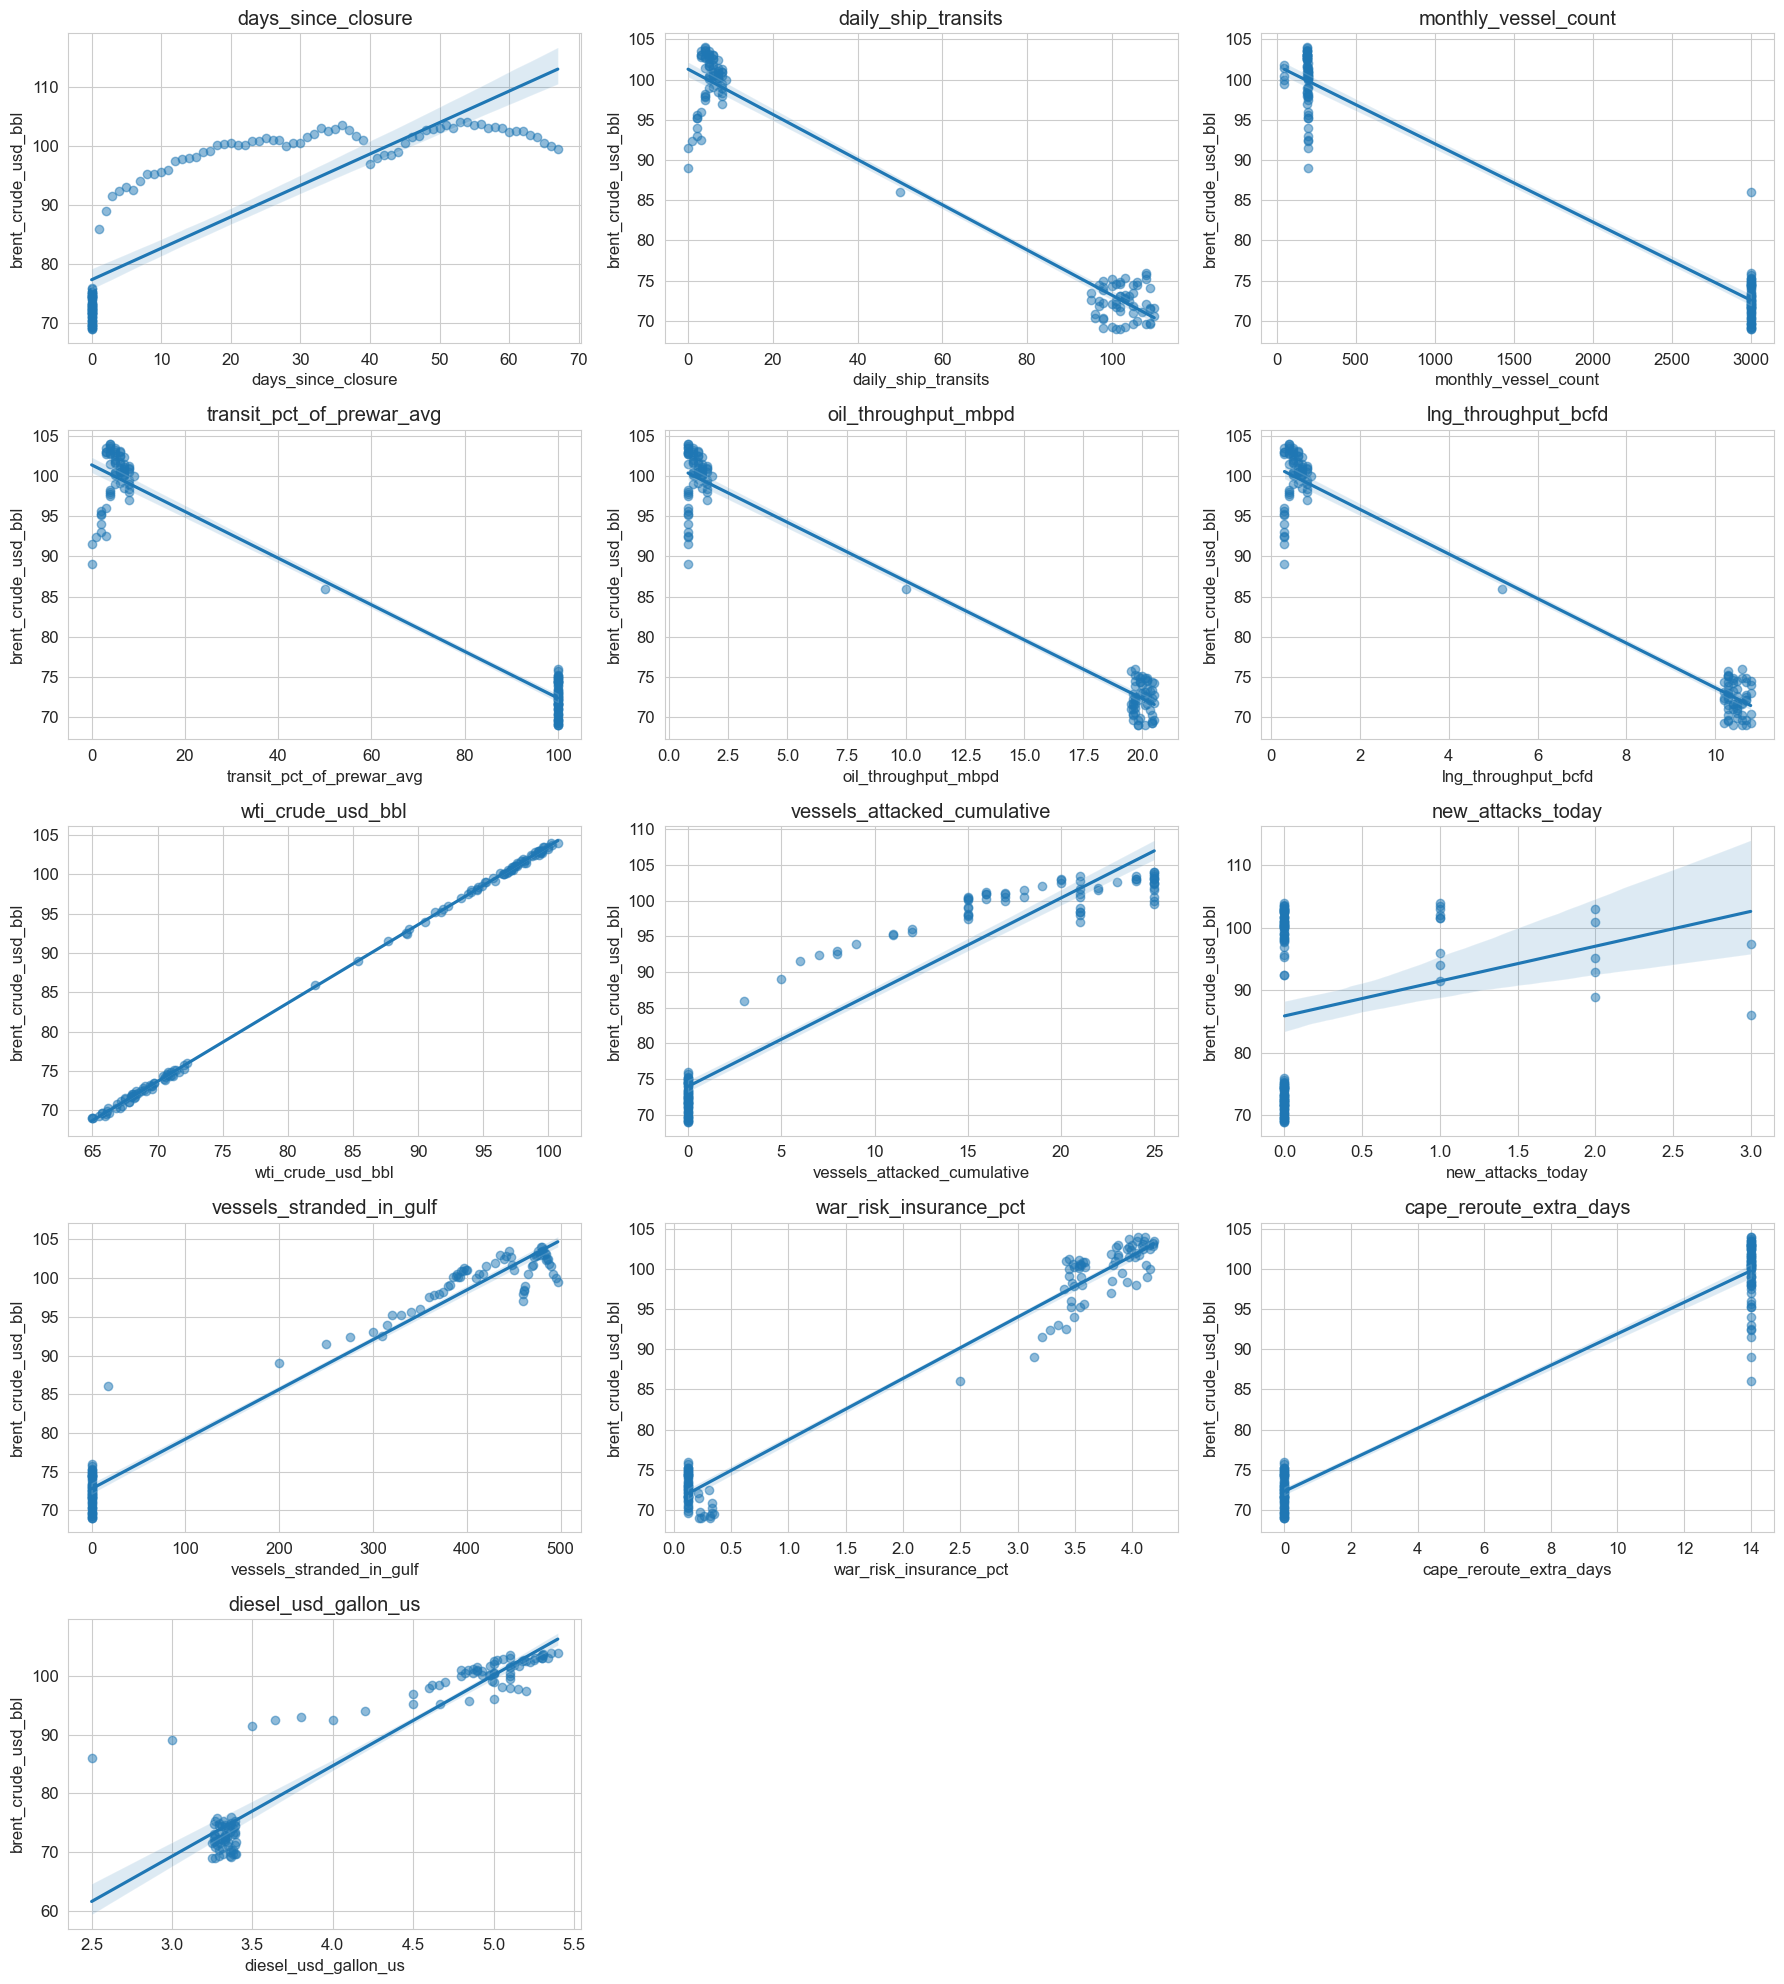

In [21]:
import math

n_features = len(features)
ncols = 3
nrows = math.ceil(n_features / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 4*nrows)
)

axes = axes.flatten()

for i, col in enumerate(features):

    sns.regplot(
        data=shipping_df,
        x=col,
        y='brent_crude_usd_bbl',
        scatter_kws={'alpha':0.5},
        ax=axes[i]
    )

    axes[i].set_title(col)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_preds = rf.predict(
    X_test
)

In [16]:
mae_rf = mean_absolute_error(
    y_test,
    rf_preds
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        rf_preds
    )
)

r2_rf = r2_score(
    y_test,
    rf_preds
)

print("Random Forest Results")

print(f"MAE  : {mae_rf:.3f}")
print(f"RMSE : {rmse_rf:.3f}")
print(f"R²   : {r2_rf:.3f}")

Random Forest Results
MAE  : 0.519
RMSE : 0.646
R²   : 0.827


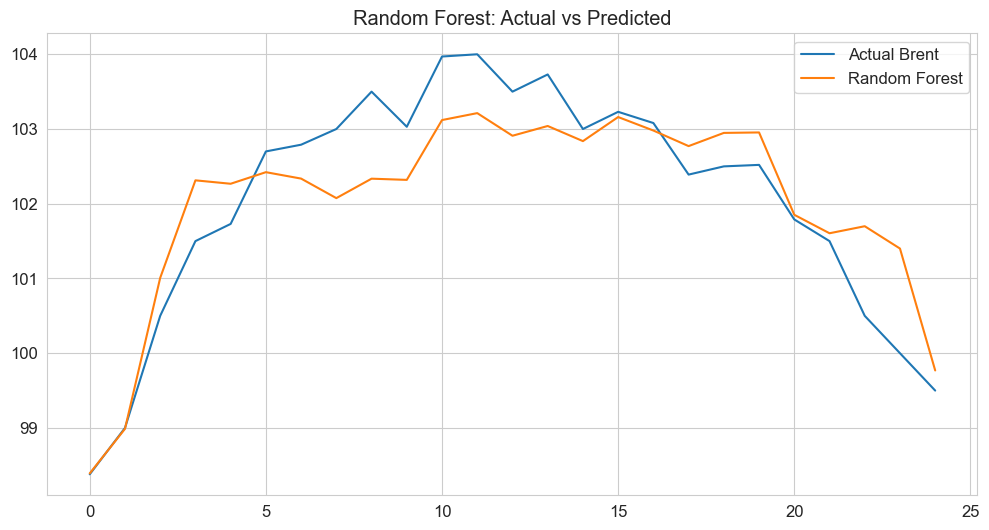

In [17]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Brent'
)

plt.plot(
    rf_preds,
    label='Random Forest'
)

plt.title(
    'Random Forest: Actual vs Predicted'
)

plt.legend()

plt.show()

In [18]:
importance_rf = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    'Importance',
    ascending=False
)

print(importance_rf)

                        Feature  Importance
6             wti_crude_usd_bbl    0.296771
10       war_risk_insurance_pct    0.152678
11      cape_reroute_extra_days    0.089259
7   vessels_attacked_cumulative    0.067975
0            days_since_closure    0.067193
4           oil_throughput_mbpd    0.060953
5           lng_throughput_bcfd    0.059433
9      vessels_stranded_in_gulf    0.053333
1           daily_ship_transits    0.044403
3     transit_pct_of_prewar_avg    0.040726
2          monthly_vessel_count    0.040350
12         diesel_usd_gallon_us    0.026727
8             new_attacks_today    0.000199


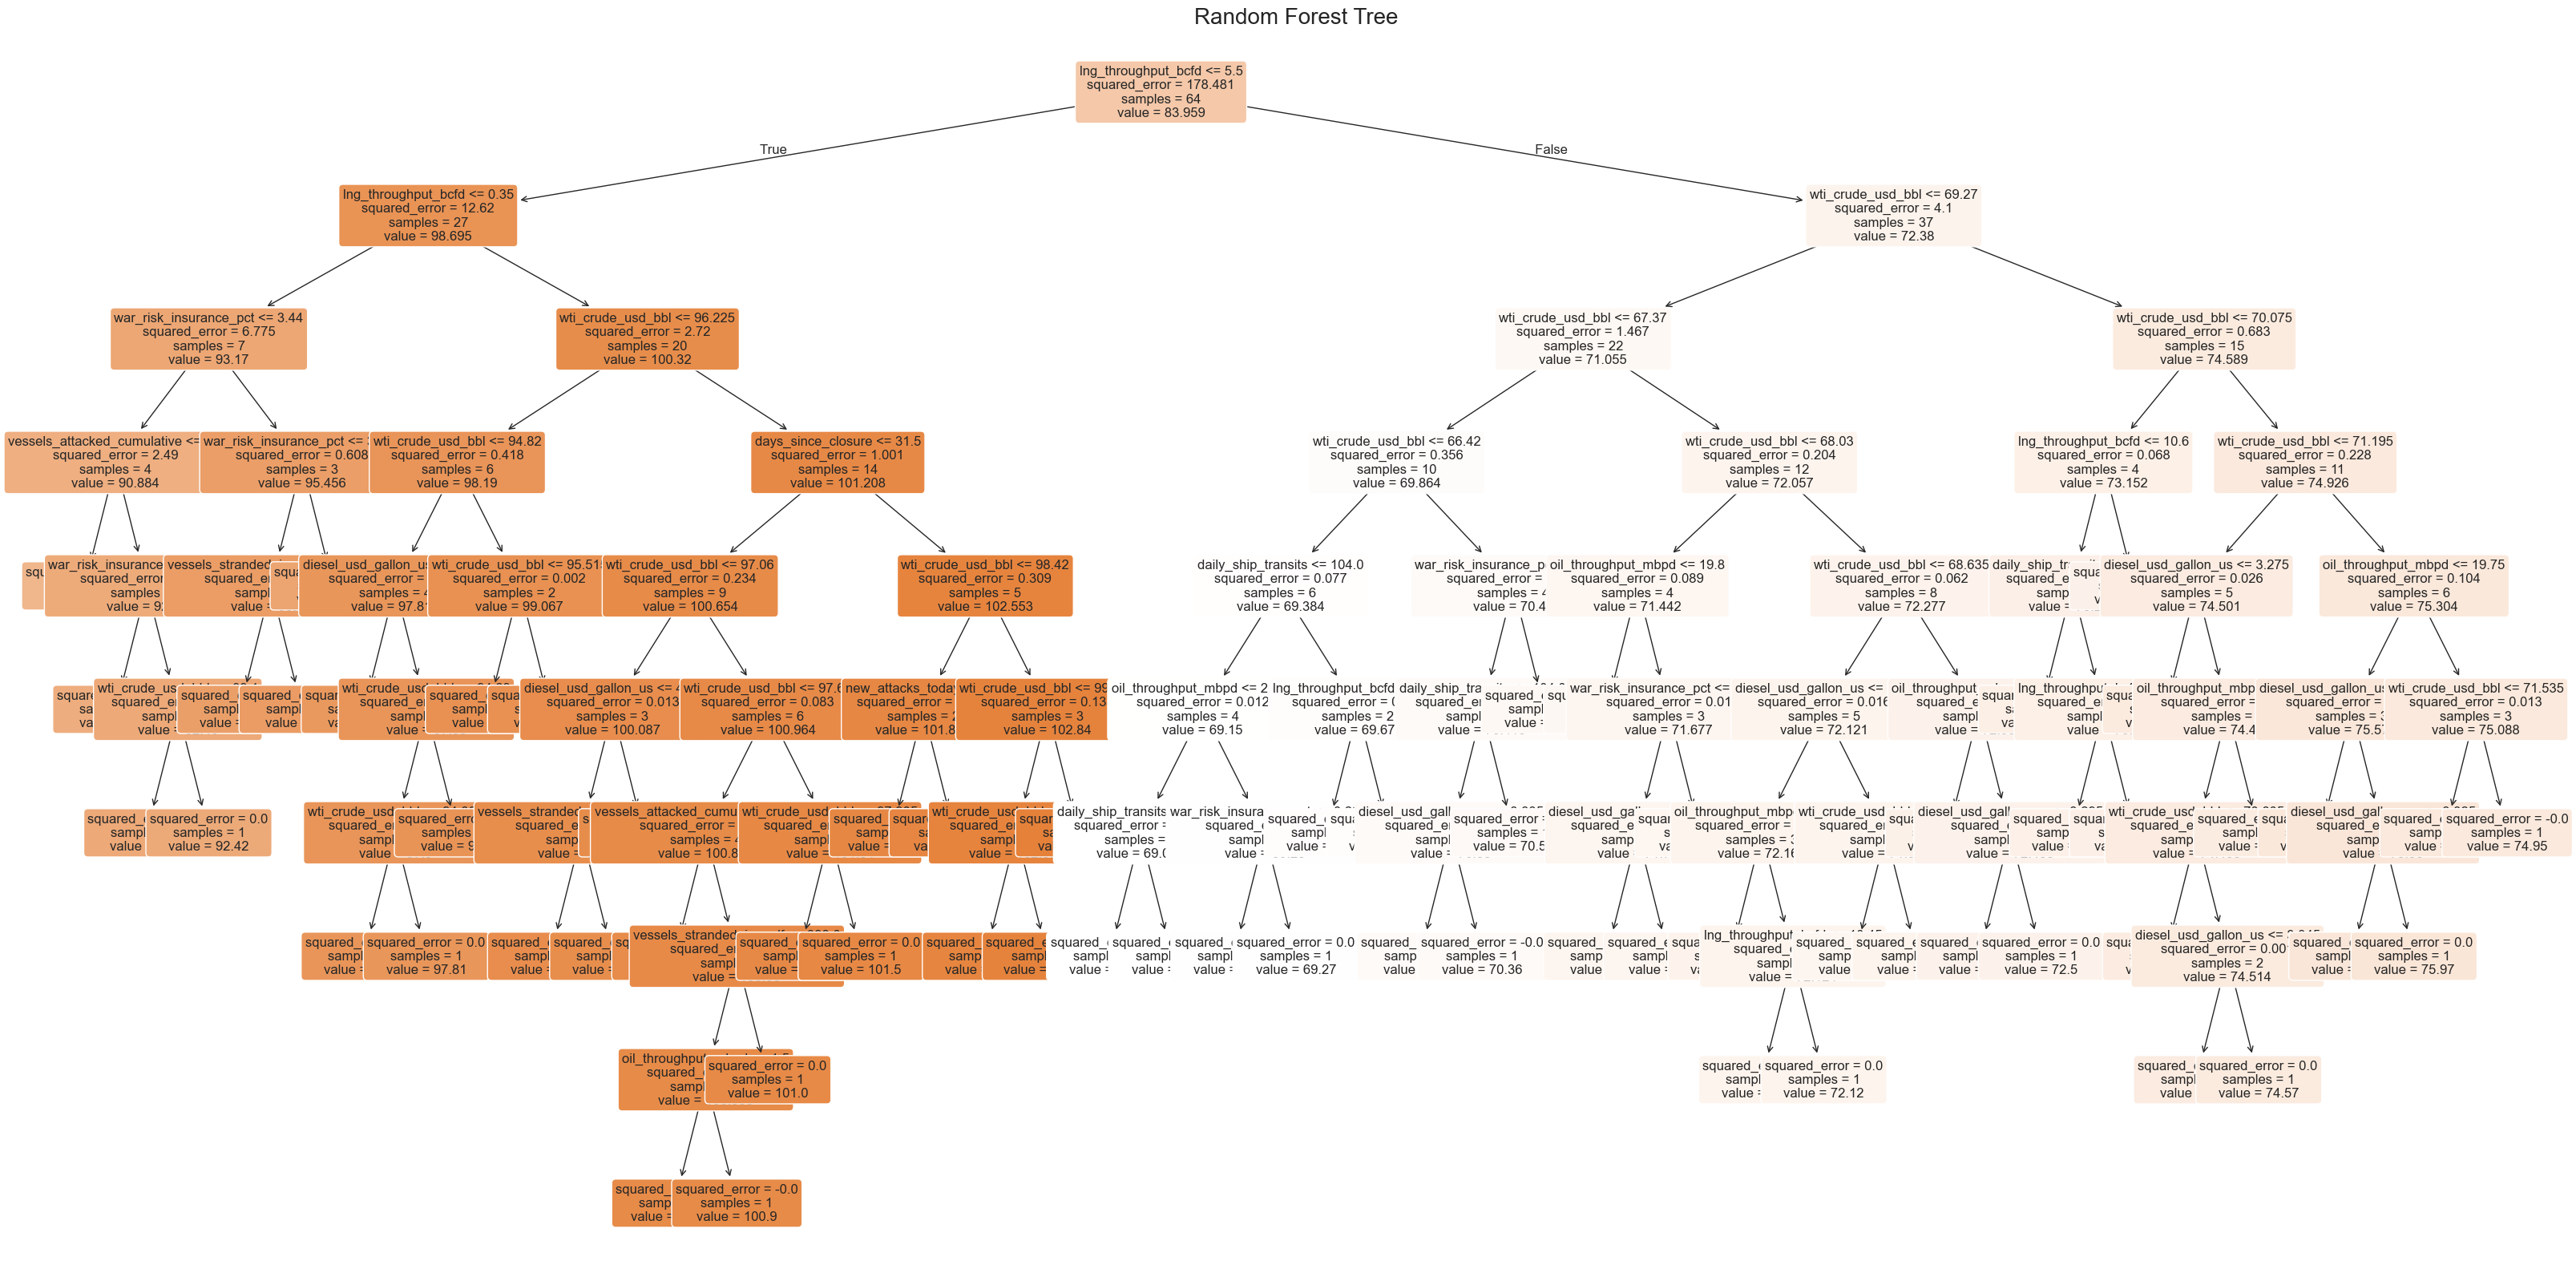

In [19]:
from sklearn.tree import plot_tree
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

tree = rf.estimators_[0]

plt.figure(figsize=(40,20))

plot_tree(
    tree,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=12
)

plt.title(
    "Random Forest Tree",
    fontsize=20
)

plt.show()